# 03 — Results analysis

Reads all per-run CSVs from `output/results/03_train_models/` and summarises model performance.

In [1]:
import glob
import os
import stylia
stylia.set_style("ersilia")
nc = stylia.NamedColors() 

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.minor.pad"] = 1   # default is 3.5
plt.rcParams['hatch.linewidth'] = 0.4  # previous pdf hatch linewidth

sns.set_theme(style="whitegrid", font_scale=1.1)

RESULTS_DIR = "../output/results/03_train_models"
FIGURES_DIR = "../output/plots"

In [2]:
# Load and concatenate all run CSVs
files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"{len(files)} run files → {len(df)} rows")

# Map pathogen codes to full names
pathogens = pd.read_csv("../config/pathogens.csv")
pathogen_codes = dict(zip(pathogens["code"], pathogens["pathogen"]))

# Add compound / active counts from selected-datasets metadata
_meta = pd.read_csv("../data/processed/01b_selected_datasets.csv")[["pathogen", "name", "compounds", "positives"]]
df = df.merge(_meta, left_on=["pathogen", "dataset"], right_on=["pathogen", "name"], how="left").drop(columns="name")
cols = [i for i in df.columns if i not in ["compounds", "positives"]]
cols = cols[:3] + ["compounds", "positives"] + cols[3:]
df = df[cols]

# Show only performance
cols = [i for i in df.columns if 'time' not in i and 'onnx' not in i]
df[cols]

33 run files → 33 rows


,pathogen,dataset,mode,compounds,positives,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc_lazy,aupr_lazy,aupr_baseline,sensitivity,specificity,auroc_rf,auroc_lr,auroc_xgb,head_score_cddd_rf,head_score_cddd_lr,head_score_cddd_xgb,pooler_cddd_mode,pooler_cddd_score,head_score_chemeleon_rf,head_score_chemeleon_lr,head_score_chemeleon_xgb,pooler_chemeleon_mode,pooler_chemeleon_score,head_score_morgan_rf,head_score_morgan_lr,head_score_morgan_xgb,pooler_morgan_mode,pooler_morgan_score,head_score_rdkit_rf,head_score_rdkit_lr,head_score_rdkit_xgb,pooler_rdkit_mode,pooler_rdkit_score,brier_score,brier_baseline,ece,prob_active_min,prob_active_p5,prob_active_p25,prob_active_p50,prob_active_p75,prob_active_p95,prob_active_max,prob_inactive_min,prob_inactive_p5,prob_inactive_p25,prob_inactive_p50,prob_inactive_p75,prob_inactive_p95,prob_inactive_max,optimal_cutoff,bedroc_lazy,calibration_y
0,abaumannii,G_ORG0_10.0,default,7763,1971,6210,1553,1577,4633,394,1159,0.9269,0.8239,0.2537,0.8756,0.8128,0.9266,NaN,0.9172,0.7047,NaN,0.7281,gating,0.7370,0.8159,NaN,0.8308,gating,0.8407,NaN,NaN,NaN,NaN,NaN,0.8224,NaN,0.8315,gating,0.8439,0.0912,0.1893,0.0363,0.0145,0.1135,0.4623,0.6871,0.8109,0.9301,0.9749,0.0086,0.0128,0.0210,0.0456,0.1908,0.5521,0.9075,0.2716,NaN,NaN
1,abaumannii,G_ORG0_10.0,fast,7763,1971,6210,1553,1577,4633,394,1159,0.9327,0.8377,0.2537,0.8376,0.8723,0.9266,NaN,0.9172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8161,NaN,0.8179,gating,0.8429,0.8224,NaN,0.8315,gating,0.8439,0.0863,0.1893,0.0202,0.0162,0.1325,0.4579,0.7169,0.8663,0.9764,0.9974,0.0084,0.0123,0.0206,0.0379,0.1460,0.5443,0.9590,0.3205,0.9201,0.0195;0.1479;0.2188;0.3514;0.4085;0.5397;0.75...
2,abaumannii,G_ORG0_10.0,slow,7763,1971,6210,1553,1577,4633,394,1159,0.9304,0.8313,0.2537,0.8655,0.8274,0.9266,NaN,0.9172,0.7047,NaN,0.7281,gating,0.7370,0.8159,NaN,0.8308,gating,0.8407,0.8161,NaN,0.8179,gating,0.8429,0.8224,NaN,0.8315,gating,0.8439,0.0891,0.1893,0.0331,0.0168,0.1231,0.4608,0.6819,0.8168,0.9383,0.9770,0.0096,0.0138,0.0226,0.0466,0.1766,0.5328,0.9270,0.2858,NaN,NaN
3,calbicans,G_ORG0_50.0,default,5718,226,4574,1144,181,4393,45,1099,0.9396,0.6365,0.0393,0.8444,0.9008,0.9363,NaN,0.9119,0.6580,0.4320,0.6953,gating,0.7032,0.7377,0.5286,0.7727,gating,0.7835,NaN,NaN,NaN,NaN,NaN,0.7630,NaN,0.7647,gating,0.7757,0.0213,0.0378,0.0193,0.0176,0.0191,0.1276,0.4132,0.6284,0.7595,0.7913,0.0170,0.0170,0.0173,0.0182,0.0199,0.0618,0.7898,0.0329,NaN,NaN
4,calbicans,G_ORG0_50.0,fast,5718,226,4574,1144,181,4393,45,1099,0.9255,0.6908,0.0393,0.7778,0.9672,0.9363,NaN,0.9119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7937,0.5997,0.7315,gating,0.7941,0.7630,NaN,0.7647,gating,0.7757,0.0192,0.0378,0.0159,0.0134,0.0156,0.1429,0.4771,0.7152,0.8379,0.8525,0.0133,0.0134,0.0138,0.0153,0.0186,0.0417,0.7798,0.0892,NaN,NaN
5,calbicans,G_ORG0_50.0,slow,5718,226,4574,1144,181,4393,45,1099,0.9343,0.6697,0.0393,0.8000,0.9490,0.9363,NaN,0.9119,0.6580,0.4320,0.6953,gating,0.7032,0.7377,0.5286,0.7727,gating,0.7835,0.7937,0.5997,0.7315,gating,0.7941,0.7630,NaN,0.7647,gating,0.7757,0.0208,0.0378,0.0202,0.0160,0.0181,0.1265,0.4101,0.6482,0.7631,0.7858,0.0155,0.0156,0.0160,0.0173,0.0200,0.0577,0.7594,0.0575,NaN,NaN
6,calbicans,G_ORG7_10.0,default,867,135,693,174,108,585,27,147,0.9393,0.7896,0.1552,0.8148,0.8639,0.9204,0.8502,0.9242,0.5842,0.6687,0.6297,gating,0.6707,0.7778,0.7611,0.7574,gating,0.7952,NaN,NaN,NaN,NaN,NaN,0.7506,NaN,0.7131,gating,0.7464,0.0668,0.1311,0.0685,0.0810,0.0857,0.2918,0.5859,0.7373,0.7989,0.8001,0.0599,0.0609,0.0635,0.0708,0.0921,0.2840,0.7263,0.1595,0.8658,0.0259;0.0952;0.2727;0.0000;1.0000;0.5000;0.50...
7,calbicans,G_ORG7_10.0,fast,867,135,693,174,108,585,27,147,0.9400,0.8114,0.1552,0.8889,0.8367,0.9204,0.8502,0.9242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7535,0.6999,0.7501,gating,0.7819,0.7506,NaN,0.7131,gating,0.7464,0.0646,0.1311,0.0713,0.0705,0.0792,0.2383,0.6692,0.7526,0.8173,0.8175,0.0614,0.0618,0.0638,0.0677,0.0849,0.3490,0.7340,0.1215,0.8922,0.0250;0.0556;0.

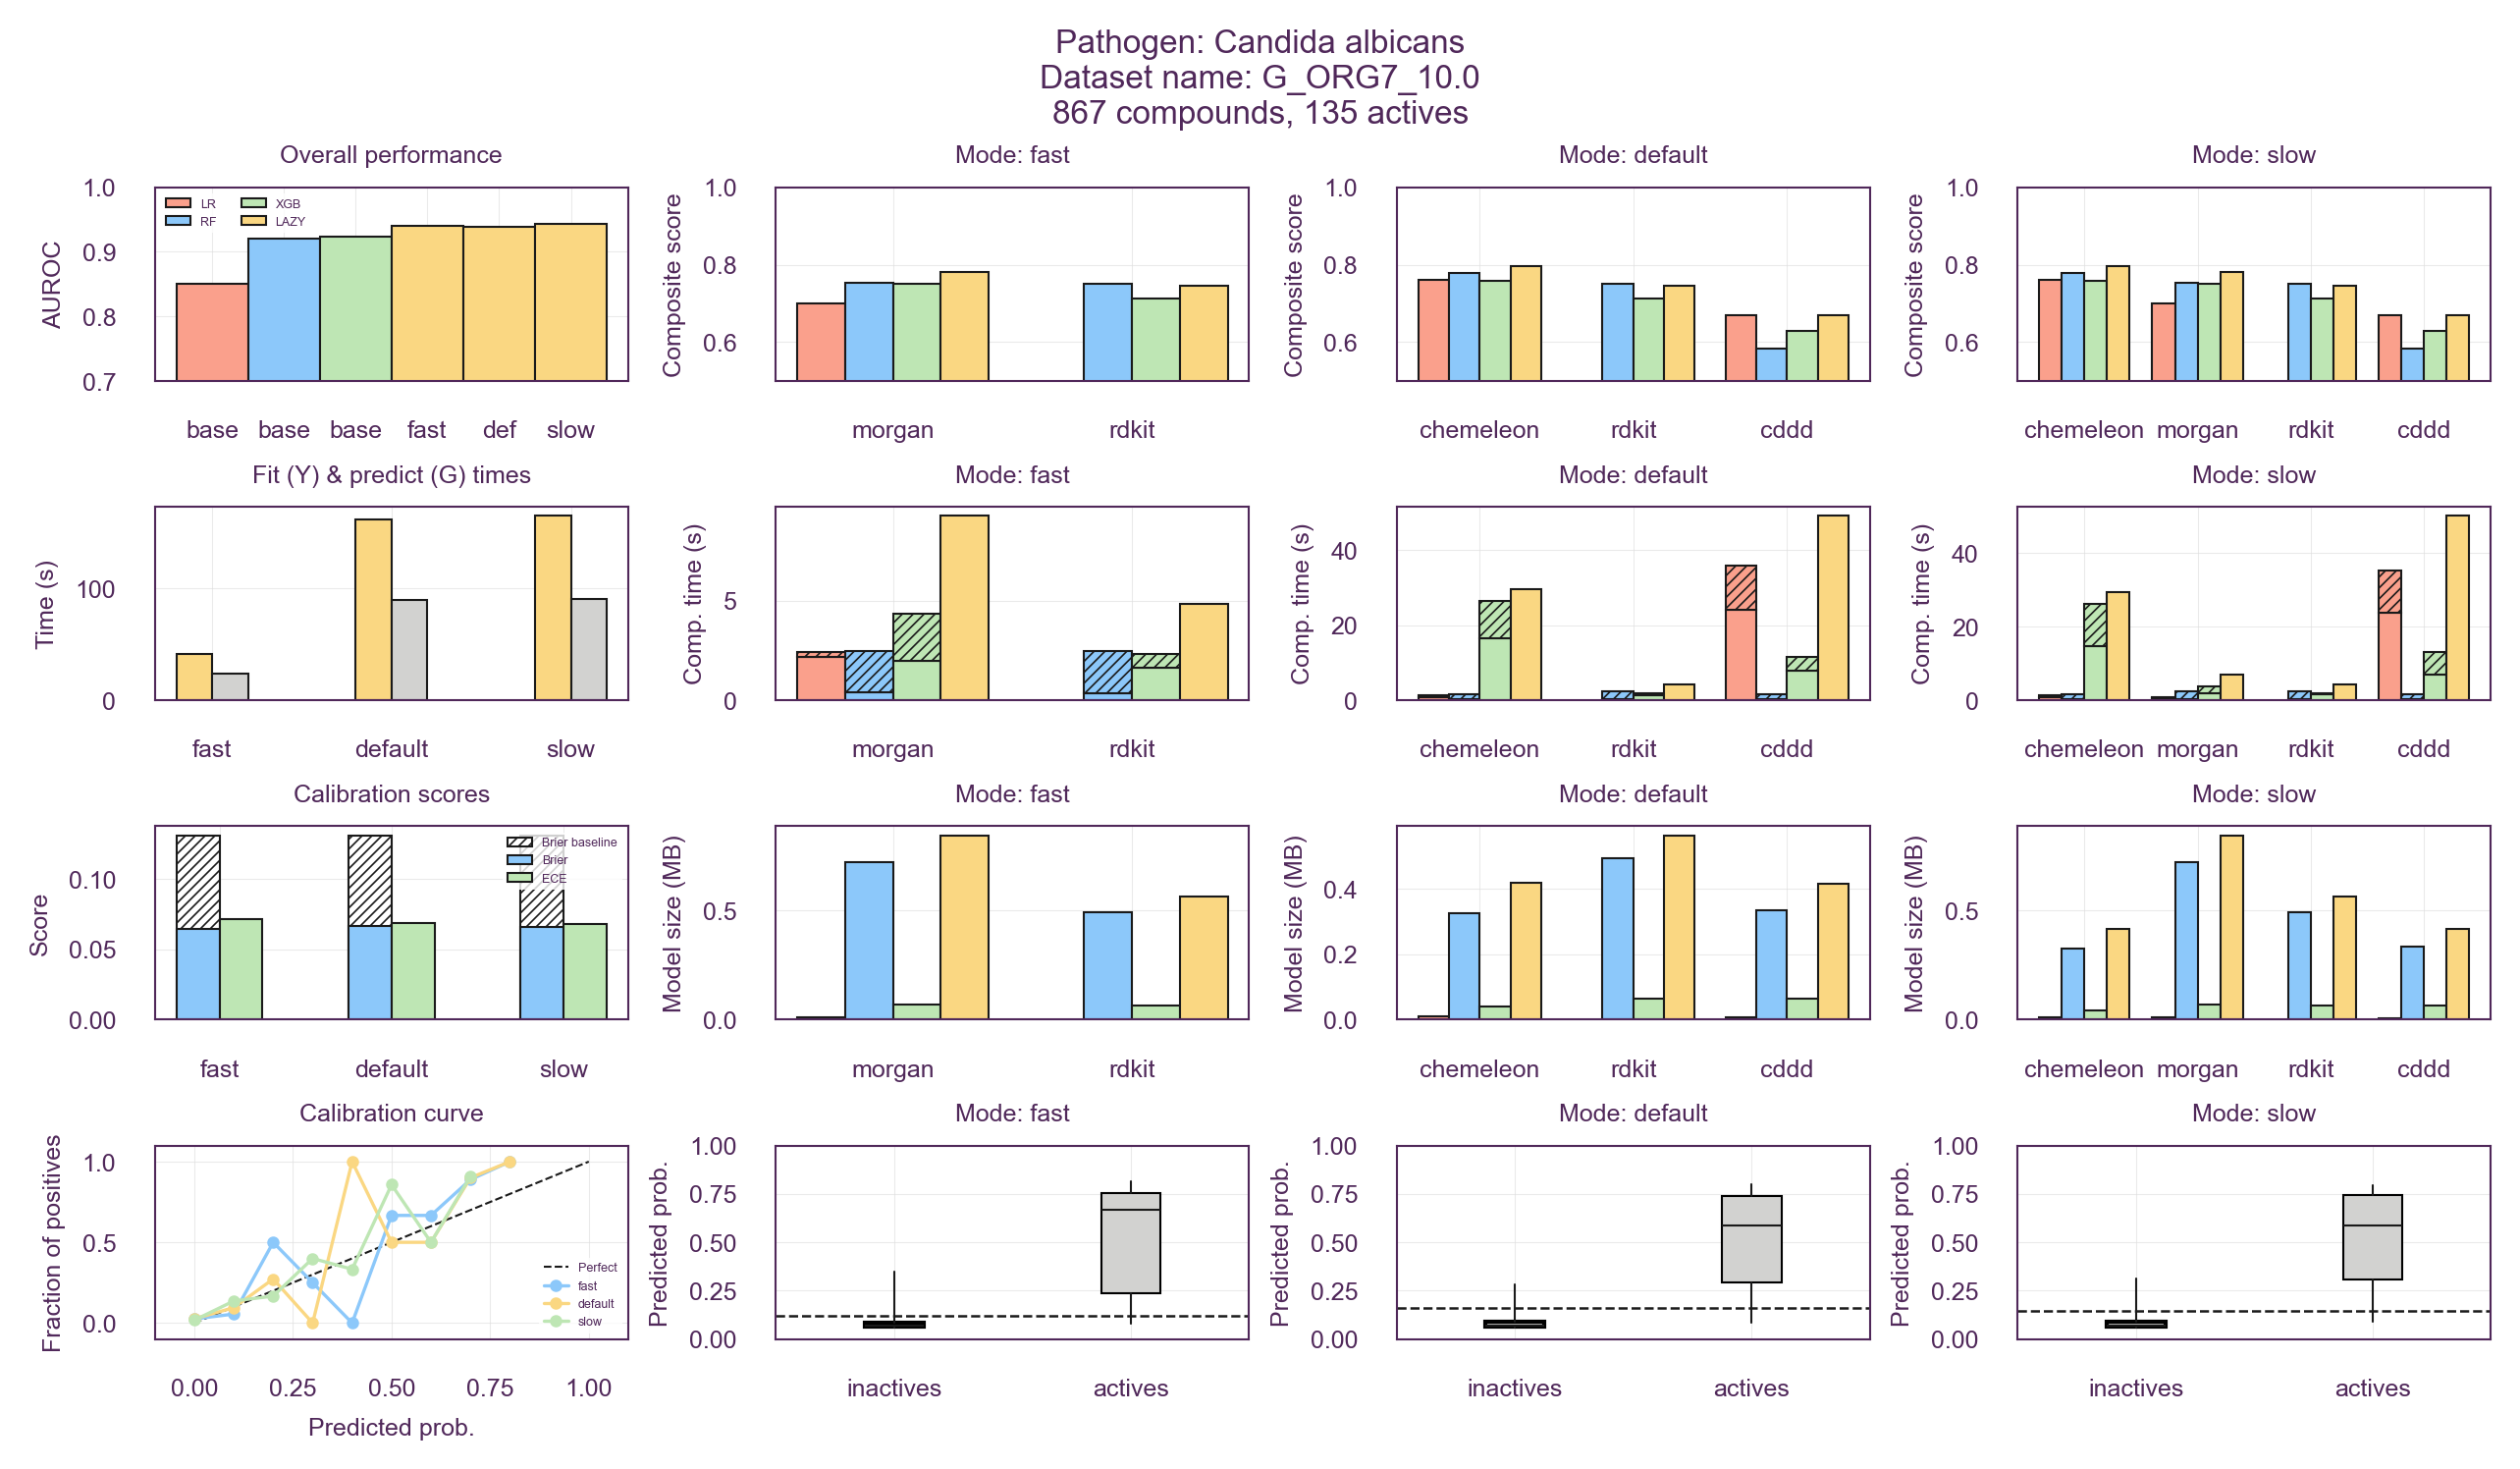

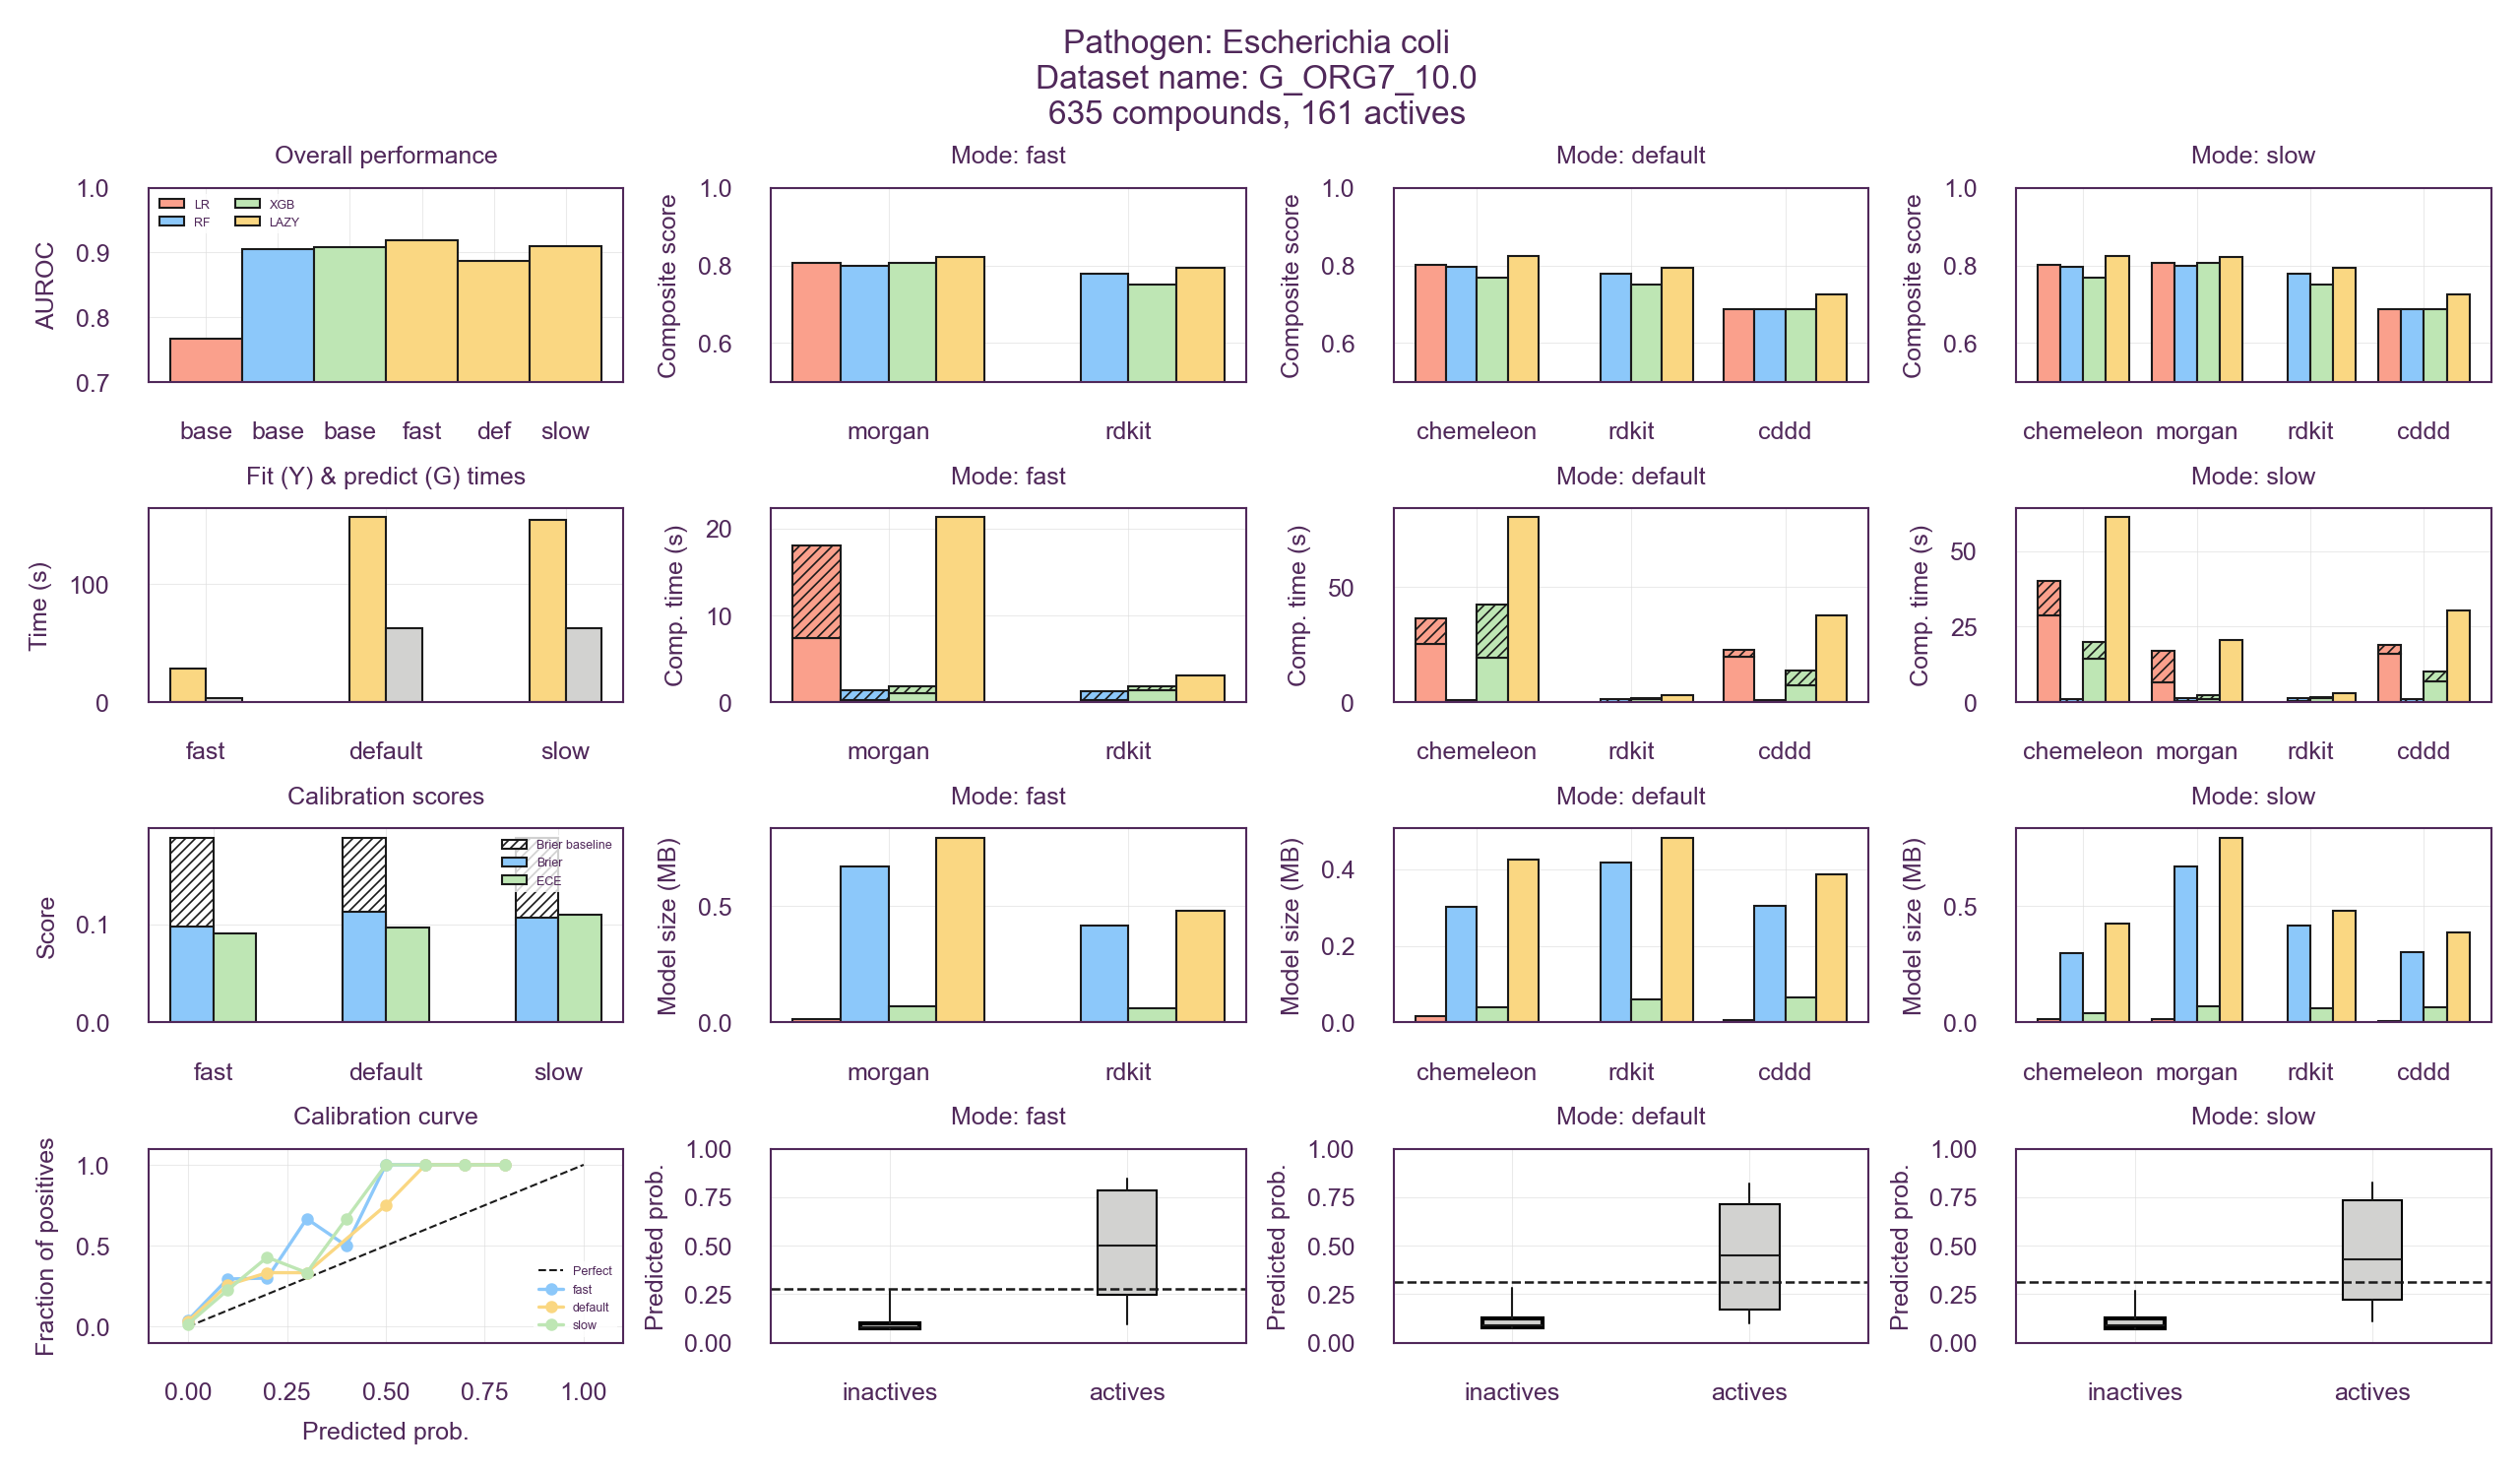

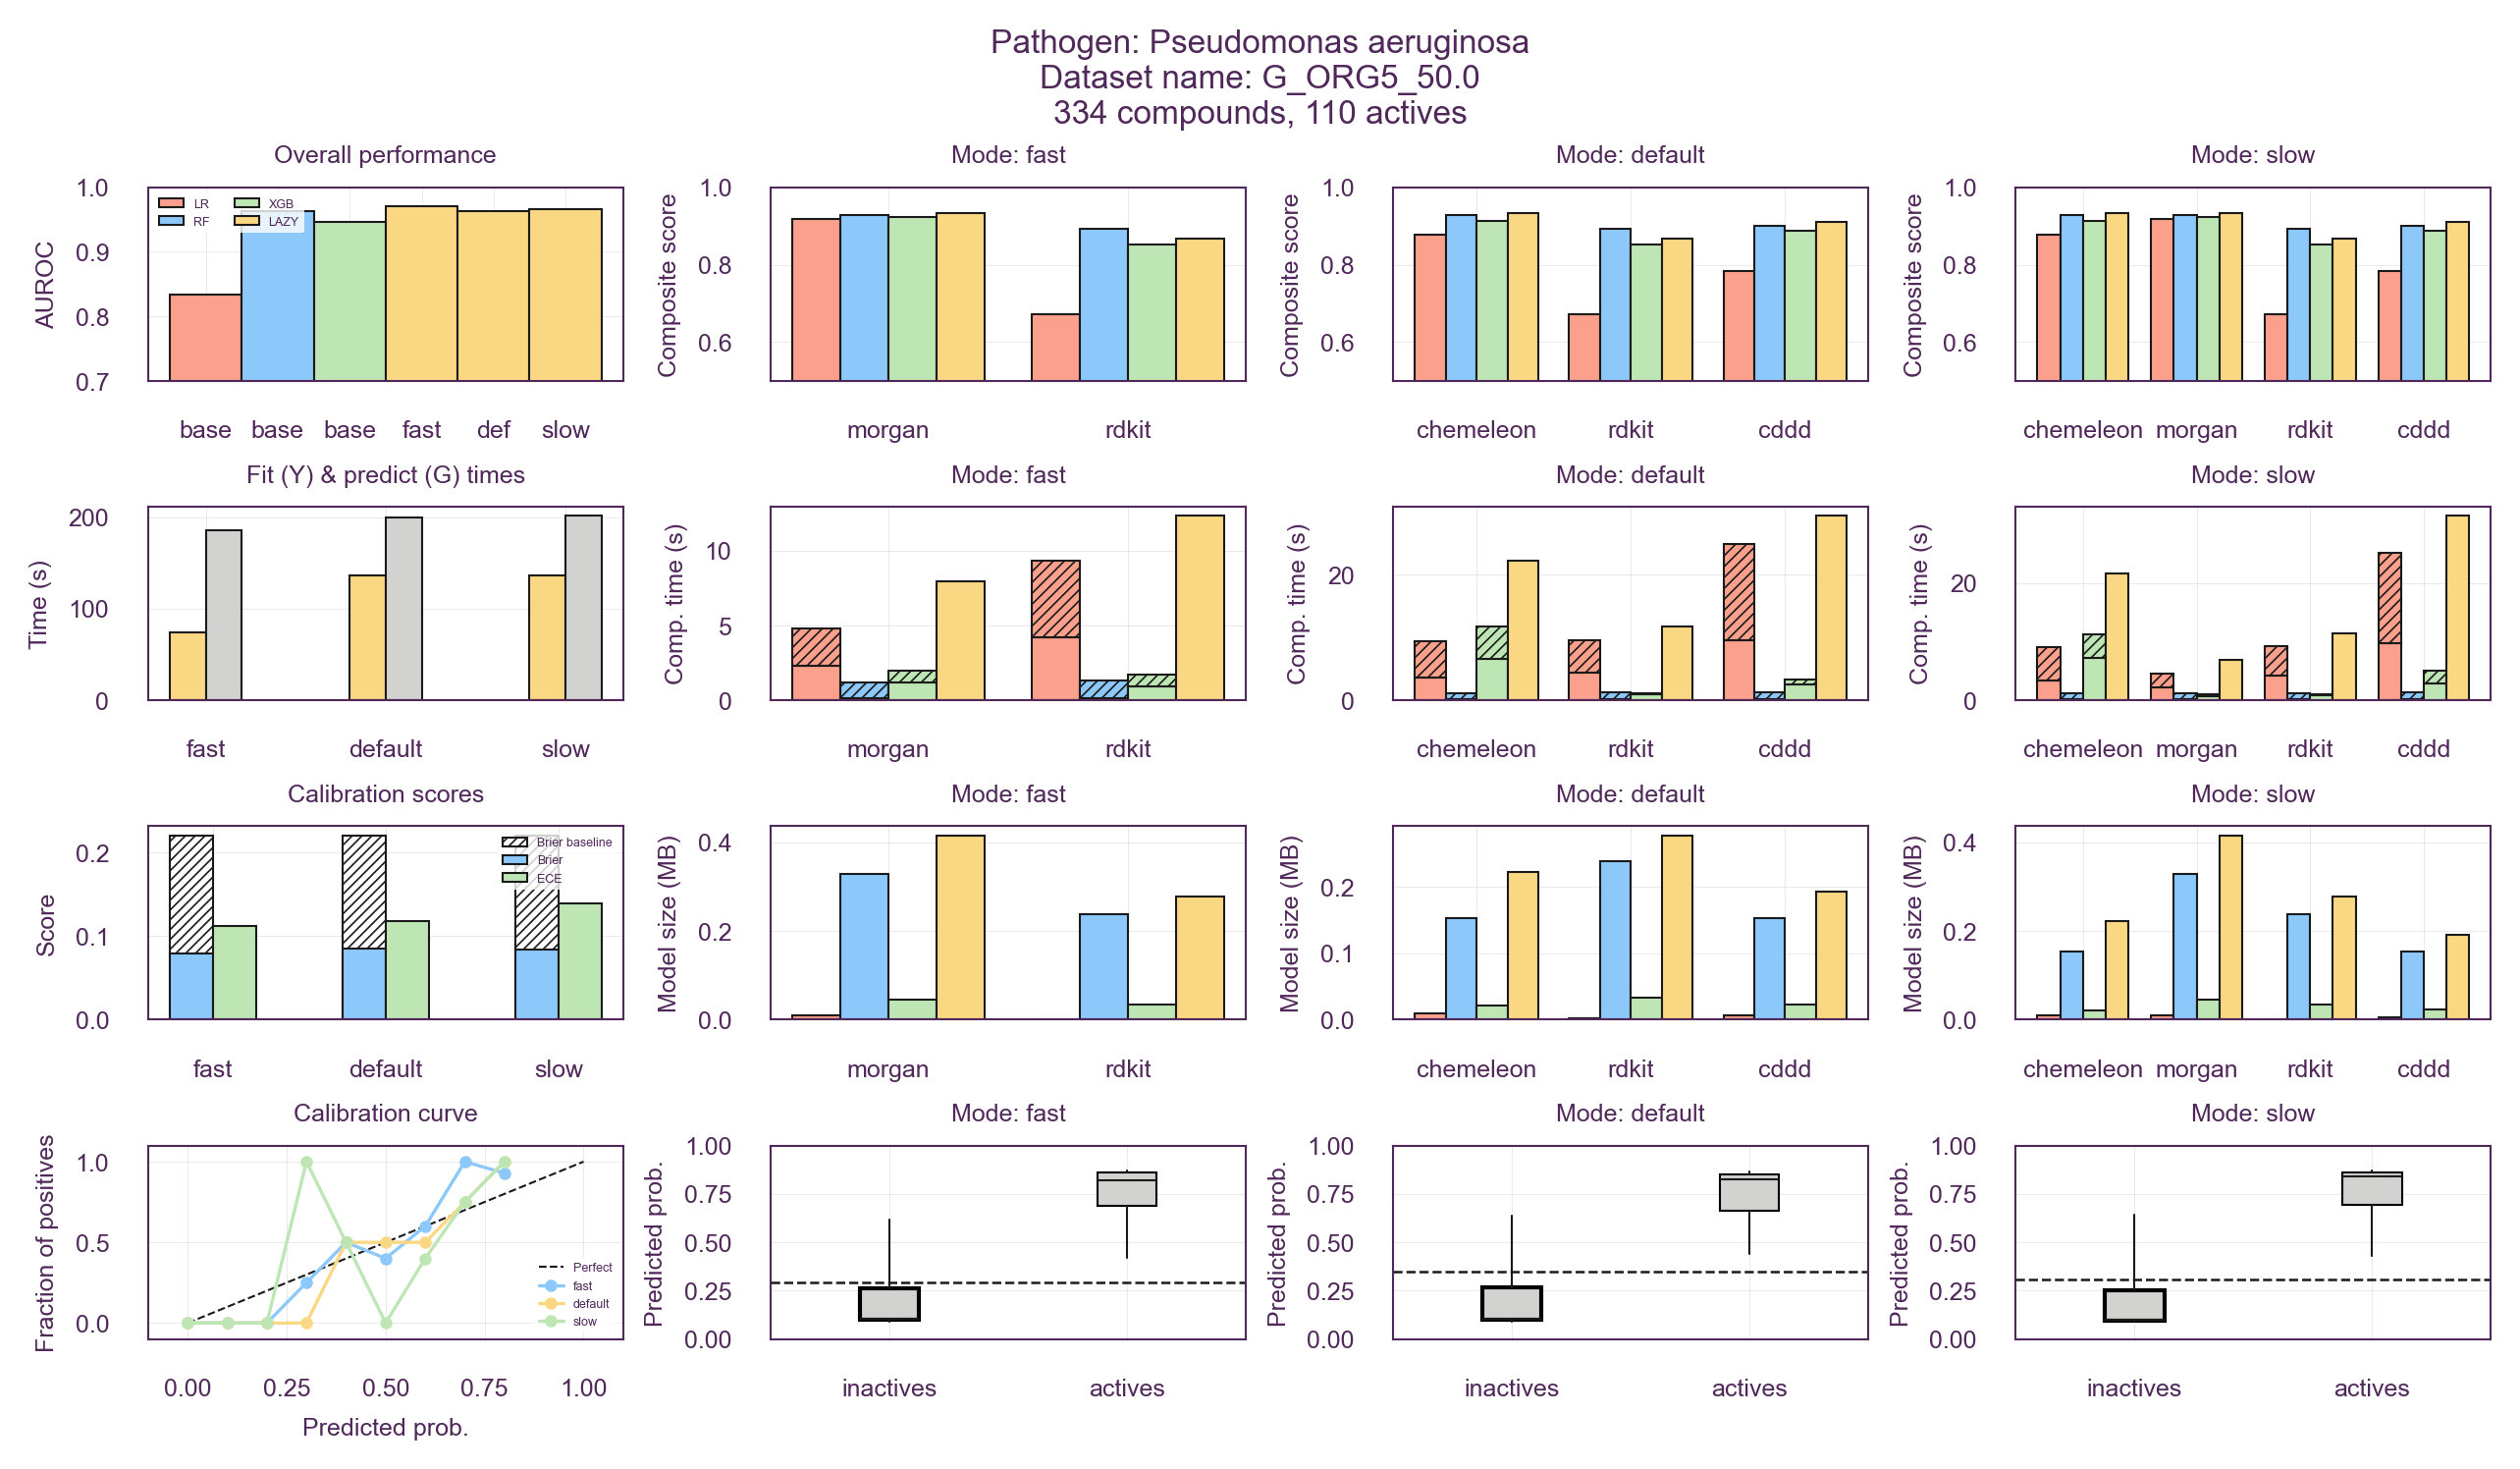

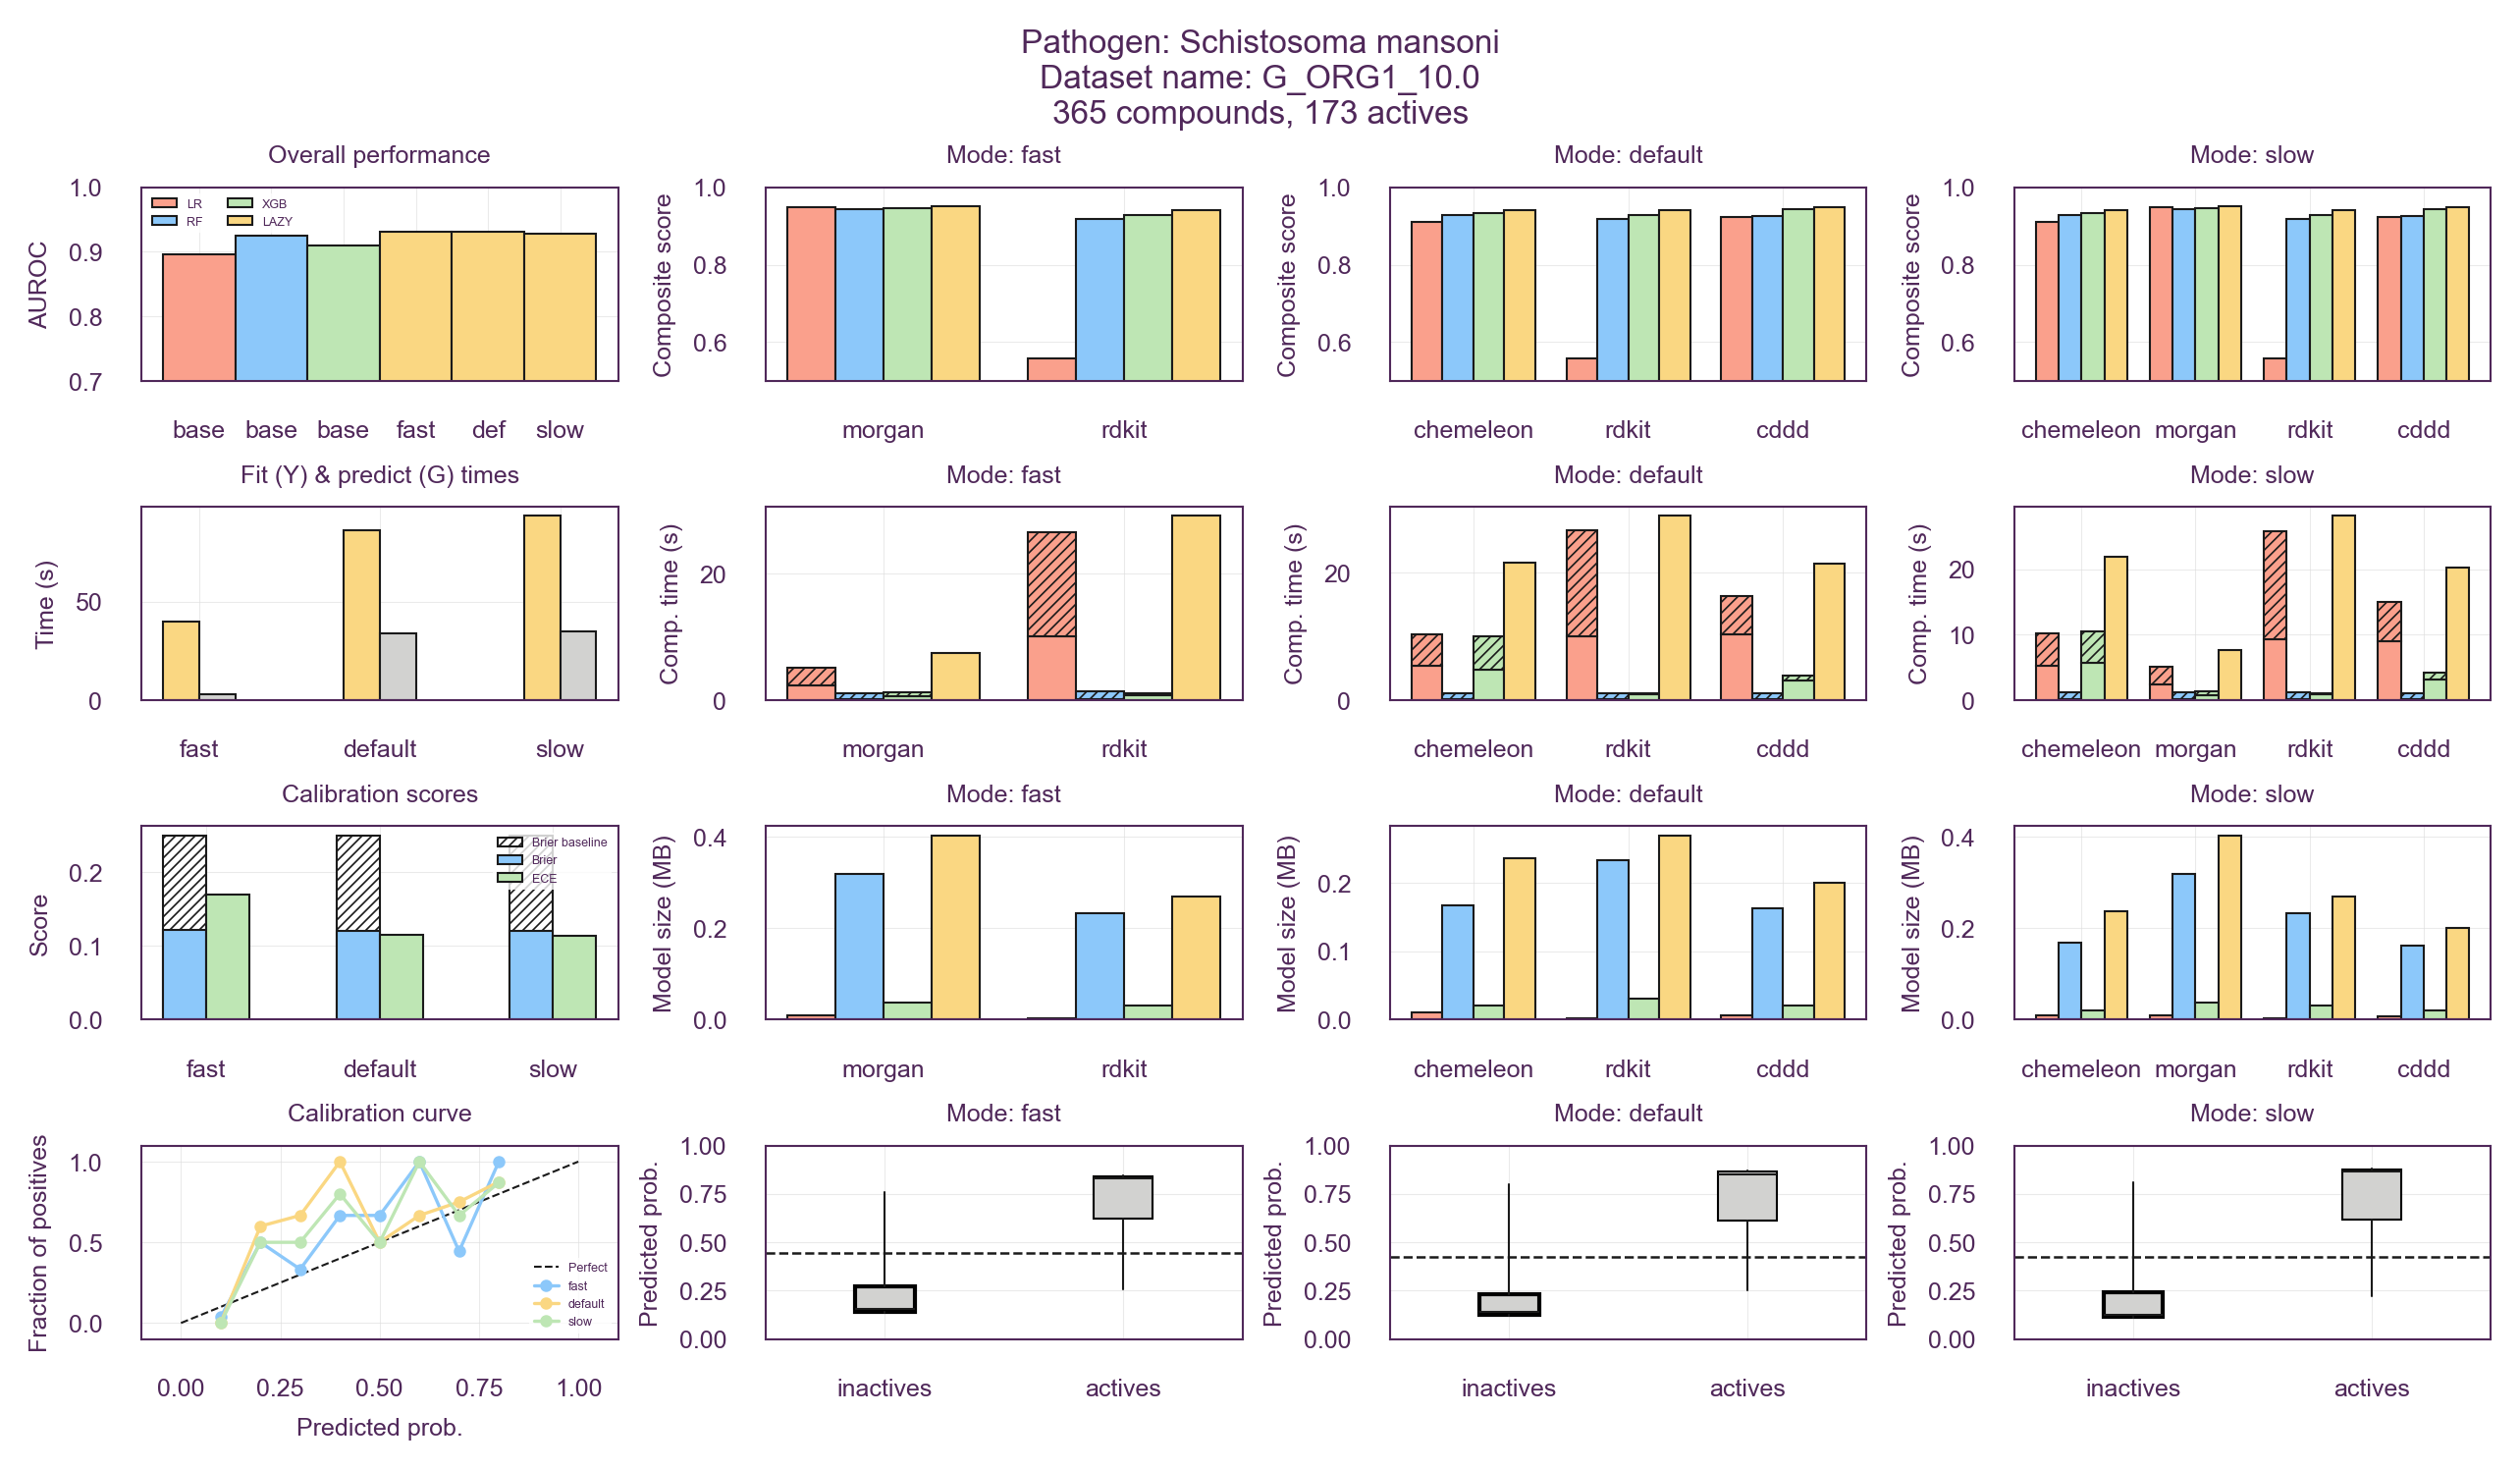

AttributeError: 'float' object has no attribute 'split'

Error in callback <function flush_figures at 0x76f65bfd8220> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [3]:
DATASETS = [["calbicans", "G_ORG7_10.0"], 
            ["ecoli", "G_ORG7_10.0"], 
            ["paeruginosa", "G_ORG5_50.0"], 
            ["smansoni", "G_ORG1_10.0"], 
            ["abaumannii", "G_ORG0_10.0"], 
            ["calbicans", "G_ORG0_50.0"], 
            ["saureus", "G_ORG6_10.0"], 
            ["mtuberculosis", "G_ORG1_10.0"], 
            ["ecoli", "G_ORG2_10.0"], 
            ["pfalciparum", "CHEMBL1054501_INHIBITION_%_qt_75.0"], 
            ["pfalciparum", "CHEMBL4888485_INHIBITION_%_qt_50.0"]]


for pathogen, dataset in DATASETS:

    df_subset = df[(df["pathogen"] == pathogen) & (df["dataset"] == dataset)]
    modes = ['fast', 'default', 'slow']

    stylia.set_format("print")

    fig, axs = stylia.create_figure(4, 4, width=1.2, height=0.7)
    actives =   df_subset["positives"].values[0]
    compounds = df_subset["compounds"].values[0]
    fig.suptitle(f"Pathogen: {pathogen_codes[pathogen]}\nDataset name: {dataset}\n{compounds} compounds, {actives} actives", fontsize=stylia.FONTSIZE_BIG)

    ################################################
    ######### BASELINE PERFORMANCE (AUROC) #########
    ################################################

    ax = axs.next()
    W = 0.2
    ax.set_title("Overall performance")
    ax.set_ylim([0.7, 1])
    ax.set_yticks([0.7, 0.8, 0.9, 1])
    ax.set_ylabel("AUROC")
    ax.bar(-3/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_lr"].mean(), color=nc.orange, width=W, ec='k', lw=0.5, label="LR")
    ax.bar(-1/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_rf"].mean(), color=nc.blue, width=W, ec='k', lw=0.5, label="RF")
    ax.bar(1/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_xgb"].mean(), color=nc.mint, width=W, ec='k', lw=0.5, label='XGB')
    ax.bar(3/2*W, df_subset[df_subset["mode"] == 'fast']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5, label='LAZY')
    ax.bar(5/2*W, df_subset[df_subset["mode"] == 'default']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.bar(7/2*W, df_subset[df_subset["mode"] == 'slow']["auroc_lazy"].mean(), color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xlabel("")
    ax.set_xticks([-3/2*W, -1/2*W, 1/2*W, 3/2*W, 5/2*W, 7/2*W])
    ax.set_xticklabels(["base", "base", "base", "fast", "def", "slow"], rotation=0)
    ax.legend(prop={'size': 3}, ncol=2, loc='upper left')

    ################################################
    ############### COMPOSITE SCORES ###############
    ################################################

    ax = axs.next()
    W = 0.2
    mode = 'fast'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylim([0.5, 1])
    ax.set_ylabel("Composite score")
    descs = ['morgan', 'rdkit']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)


    ax = axs.next()
    W = 0.2
    mode = 'default'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylim([0.5, 1])
    ax.set_ylabel("Composite score")
    descs = ['chemeleon', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)


    ax = axs.next()
    W = 0.2
    mode = 'slow'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylim([0.5, 1])
    ax.set_ylabel("Composite score")
    descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_lr"].values[0], color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_rf"].values[0], color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"head_score_{desc}_xgb"].values[0], color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"pooler_{desc}_score"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)



    ################################################
    ################## TIMES ###################
    ################################################

    ax = axs.next()
    W = 0.2
    ax.set_title("Fit (Y) & predict (G) times")
    ax.set_ylabel("Time (s)")
    ax.set_xlabel("")
    for x, mode in enumerate(['fast', 'default', 'slow']):
        fit_t  = df_subset[df_subset['mode'] == mode]['time_lazyqsar_fit_s'].values[0]
        pred_t = df_subset[df_subset['mode'] == mode]['predict_time_1k_s'].values[0]
        ax.bar(x - W/2, fit_t,  color=nc.yellow, width=W, ec='k', lw=0.5, label='fit'     if x == 0 else '')
        ax.bar(x + W/2, pred_t, color=nc.gray,   width=W, ec='k', lw=0.5, label='pred/1k' if x == 0 else '')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['fast', 'default', 'slow'])

    ax = axs.next()
    W = 0.2
    mode = 'fast'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Comp. time (s)")
    descs = ['morgan', 'rdkit']
    for x, desc in enumerate(descs):
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
        ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
        ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
        ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)

    ax = axs.next()
    W = 0.2
    mode = 'default'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Comp. time (s)")
    descs = ['chemeleon', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
        ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
        ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
        ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)


    ax = axs.next()
    W = 0.2
    mode = 'slow'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Comp. time (s)")
    descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_lr_calibration_s"].values[0]
        ax.bar(x - 3/2*W, fit, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 3/2*W, bottom=fit, height=cal, color=nc.orange, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_rf_calibration_s"].values[0]
        ax.bar(x - 1/2*W, fit, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, bottom=fit, height=cal, color=nc.blue, width=W, ec='k', lw=0.5, hatch='/////////')
        fit = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_fit_s"].values[0]
        cal = df_subset[df_subset['mode'] == mode][f"time_{desc}_xgb_calibration_s"].values[0]
        ax.bar(x + 1/2*W, fit, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, bottom=fit, height=cal, color=nc.mint, width=W, ec='k', lw=0.5, hatch='/////////')
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"time_{desc}_total_s"].values[0], color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)

    ################################################
    ################# CAL. SCORES ##################
    ################################################

    ax = axs.next()
    ax.set_title("Calibration scores")
    W = 0.25
    for x, mode in enumerate(modes):
        row = df_subset[df_subset['mode'] == mode].iloc[0]
        ax.bar(x - W/2, row['brier_baseline'], color="w", width=W, ec='k', lw=0.5, label='Brier baseline' if x == 0 else '', hatch="//" * 5)
        ax.bar(x - W/2, row['brier_score'], color=nc.blue, width=W, ec='k', lw=0.5, label='Brier' if x == 0 else '')
        ax.bar(x + W/2, row['ece'],          color=nc.mint, width=W, ec='k', lw=0.5, label='ECE'   if x == 0 else '')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(modes)
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.legend(prop={'size': 3})


    ################################################
    ################## ONNX SIZE ###################
    ################################################


    ax = axs.next()
    W = 0.2
    mode = 'fast'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Model size (MB)")
    descs = ['morgan', 'rdkit']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)


    ax = axs.next()
    W = 0.2
    mode = 'default'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Model size (MB)")
    descs = ['chemeleon', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)

    ax = axs.next()
    W = 0.2
    mode = 'slow'
    ax.set_title(f"Mode: {mode}")
    ax.set_xlabel("")
    ax.set_ylabel("Model size (MB)")
    descs = ['chemeleon', 'morgan', 'rdkit', 'cddd']
    for x, desc in enumerate(descs):
        ax.bar(x - 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_lr_kb"].values[0]/1000, color=nc.orange, width=W, ec='k', lw=0.5)
        ax.bar(x - 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_rf_kb"].values[0]/1000, color=nc.blue, width=W, ec='k', lw=0.5)
        ax.bar(x + 1/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_xgb_kb"].values[0]/1000, color=nc.mint, width=W, ec='k', lw=0.5)
        ax.bar(x + 3/2*W, df_subset[df_subset['mode'] == mode][f"onnx_{desc}_total_kb"].values[0]/1000, color=nc.yellow, width=W, ec='k', lw=0.5)
    ax.set_xticks([i for i in range(len(descs))])
    ax.set_xticklabels(descs, rotation=0)


    ################################################
    ############# CALIBRATION CURVE ################
    ################################################

    ax = axs.next()
    ax.set_title("Calibration curve")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.5, label='Perfect')
    cal_x = list(np.arange(0, 1, 0.1))  # fixed x for all runs: [0.0, 0.1, ..., 0.9]
    colors_map = {'fast': nc.blue, 'default': nc.yellow, 'slow': nc.mint}
    for mode in modes:
        row = df_subset[df_subset['mode'] == mode].iloc[0]
        cal_y_raw = [float(v) for v in row['calibration_y'].split(';')]
        xs = [x for x, y in zip(cal_x, cal_y_raw) if not np.isnan(y)]
        ys = [y for y in cal_y_raw if not np.isnan(y)]
        ax.plot(xs, ys, color=colors_map[mode], lw=0.8, marker='o', markersize=2, label=mode)
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel("")
    ax.set_xlabel("Predicted prob.")
    ax.set_ylabel("Fraction of positives")
    ax.legend(prop={'size': 3}, loc='lower right')


    ################################################
    ######### PREDICTED PROBABILITY DIST ###########
    ################################################

    for mode in ['fast', 'default', 'slow']:
        ax = axs.next()
        row = df_subset[df_subset['mode'] == mode].iloc[0]

        stats_inact = dict(
            med=row['prob_inactive_p50'], q1=row['prob_inactive_p25'], q3=row['prob_inactive_p75'],
            whislo=row['prob_inactive_p5'], whishi=row['prob_inactive_p95'], fliers=[]
        )
        stats_act = dict(
            med=row['prob_active_p50'], q1=row['prob_active_p25'], q3=row['prob_active_p75'],
            whislo=row['prob_active_p5'], whishi=row['prob_active_p95'], fliers=[]
        )

        bp = ax.bxp([stats_inact, stats_act], positions=[0, 1], widths=0.25,
                    patch_artist=True, showfliers=False)
        bp['boxes'][0].set_facecolor(nc.gray)
        bp['boxes'][1].set_facecolor(nc.gray)
        bp['boxes'][1].set_linewidth(0.5)
        for element in ['whiskers', 'caps', 'medians']:
            for line in bp[element]:
                line.set_color('k')
                line.set_linewidth(0.5)
                if element == 'caps': line.set_linewidth(0)

        ax.axhline(row['optimal_cutoff'], color='k', linestyle='--', lw=0.6, label=f"cutoff={row['optimal_cutoff']:.2f}")
        ax.set_ylim([0, 1])
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['inactives', 'actives'])
        ax.set_title(f"Mode: {mode}")
        ax.set_ylabel("Predicted prob.")
        ax.set_xlabel("")

    plt.tight_layout()
    plt.show()